Multilayer Perceptron Implementation

=== XOR Problem Demo ===
Epoch    0: Loss = 0.725192, Accuracy = 0.5000
Epoch  100: Loss = 0.667496, Accuracy = 0.7500
Epoch  200: Loss = 0.348055, Accuracy = 1.0000
Epoch  300: Loss = 0.099873, Accuracy = 1.0000
Epoch  400: Loss = 0.049920, Accuracy = 1.0000
Epoch  500: Loss = 0.032265, Accuracy = 1.0000
Epoch  600: Loss = 0.023575, Accuracy = 1.0000
Epoch  700: Loss = 0.018475, Accuracy = 1.0000
Epoch  800: Loss = 0.015142, Accuracy = 1.0000
Epoch  900: Loss = 0.012802, Accuracy = 1.0000
Epoch 1000: Loss = 0.011073, Accuracy = 1.0000
Epoch 1100: Loss = 0.009746, Accuracy = 1.0000
Epoch 1200: Loss = 0.008695, Accuracy = 1.0000
Epoch 1300: Loss = 0.007844, Accuracy = 1.0000
Epoch 1400: Loss = 0.007140, Accuracy = 1.0000
Epoch 1500: Loss = 0.006550, Accuracy = 1.0000
Epoch 1600: Loss = 0.006047, Accuracy = 1.0000
Epoch 1700: Loss = 0.005614, Accuracy = 1.0000
Epoch 1800: Loss = 0.005237, Accuracy = 1.0000
Epoch 1900: Loss = 0.004906, Accuracy = 1.00

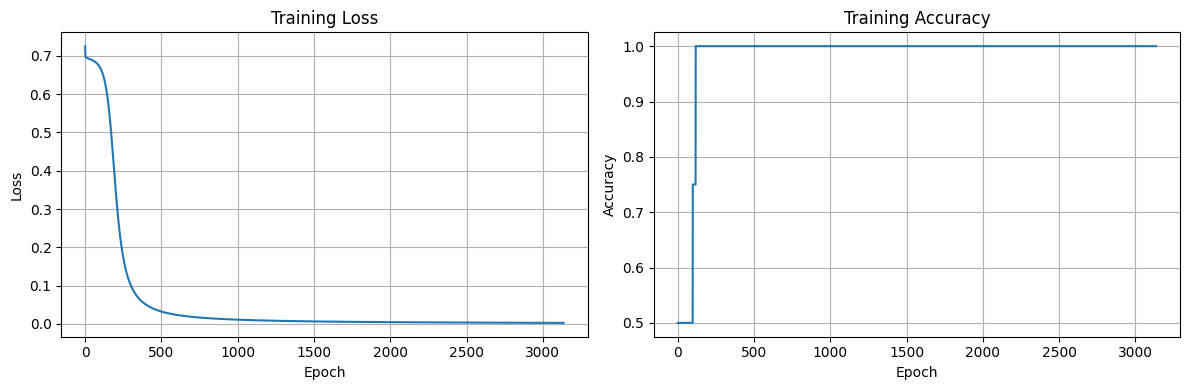

=== Binary Classification Demo ===
Epoch    0: Loss = 9.271341, Accuracy = 0.4963
           Val Loss = 2.195301, Val Accuracy = 0.5000
Epoch  100: Loss = 0.048976, Accuracy = 0.9962
           Val Loss = 4.406252, Val Accuracy = 0.5000
Epoch  200: Loss = 0.042501, Accuracy = 0.9988
           Val Loss = 4.538629, Val Accuracy = 0.5000
Epoch  300: Loss = 0.038819, Accuracy = 1.0000
           Val Loss = 4.581196, Val Accuracy = 0.5000
Epoch  400: Loss = 0.036227, Accuracy = 1.0000
           Val Loss = 4.627755, Val Accuracy = 0.5000
Epoch  500: Loss = 0.034439, Accuracy = 1.0000
           Val Loss = 4.717610, Val Accuracy = 0.5000
Epoch  600: Loss = 0.033225, Accuracy = 1.0000
           Val Loss = 4.657420, Val Accuracy = 0.5000
Epoch  700: Loss = 0.032376, Accuracy = 1.0000
           Val Loss = 4.668001, Val Accuracy = 0.5000
Epoch  800: Loss = 0.031760, Accuracy = 1.0000
           Val Loss = 4.676663, Val Accuracy = 0.5000
Epoch  900: Loss = 0.031287, Accuracy = 1.0000
         

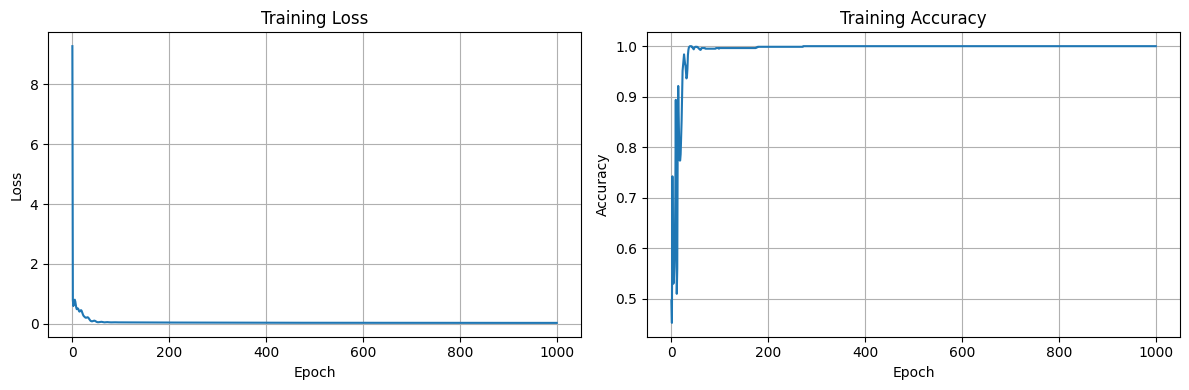

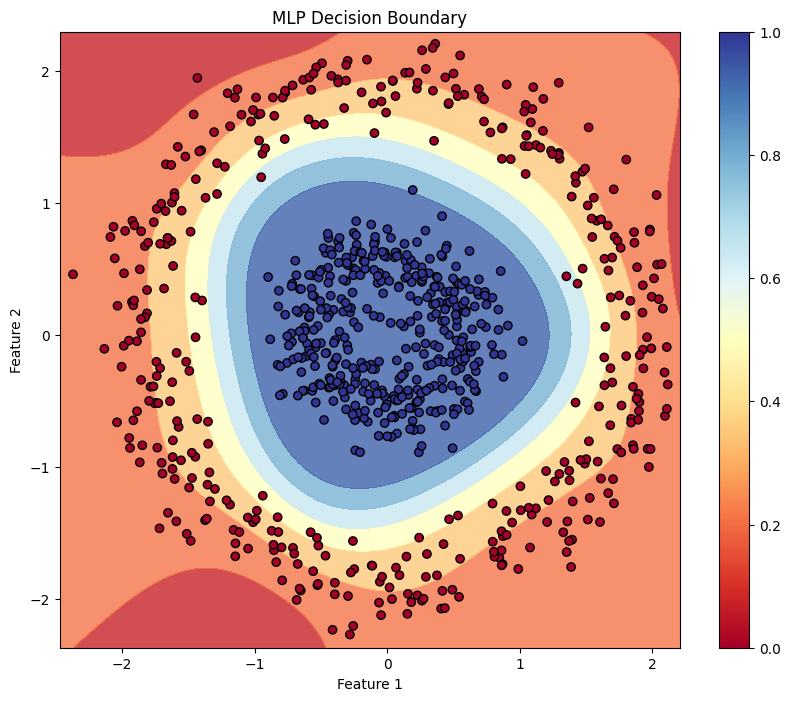


=== Multi-class Classification Demo ===
Epoch    0: Loss = 1.159970, Accuracy = 0.3262
           Val Loss = 1.203929, Val Accuracy = 0.2900
Epoch  100: Loss = 0.427960, Accuracy = 0.8825
           Val Loss = 0.466219, Val Accuracy = 0.8550
Epoch  200: Loss = 0.297138, Accuracy = 0.8862
           Val Loss = 0.324082, Val Accuracy = 0.8650
Epoch  300: Loss = 0.260509, Accuracy = 0.8888
           Val Loss = 0.290950, Val Accuracy = 0.8700
Epoch  400: Loss = 0.244816, Accuracy = 0.8888
           Val Loss = 0.277507, Val Accuracy = 0.8800
Epoch  500: Loss = 0.235738, Accuracy = 0.8900
           Val Loss = 0.269792, Val Accuracy = 0.8900
Epoch  600: Loss = 0.227793, Accuracy = 0.8962
           Val Loss = 0.263904, Val Accuracy = 0.8900
Epoch  700: Loss = 0.220666, Accuracy = 0.9000
           Val Loss = 0.259488, Val Accuracy = 0.8900
Epoch  800: Loss = 0.213873, Accuracy = 0.9050
           Val Loss = 0.254431, Val Accuracy = 0.9000
Epoch  900: Loss = 0.207337, Accuracy = 0.9062
   

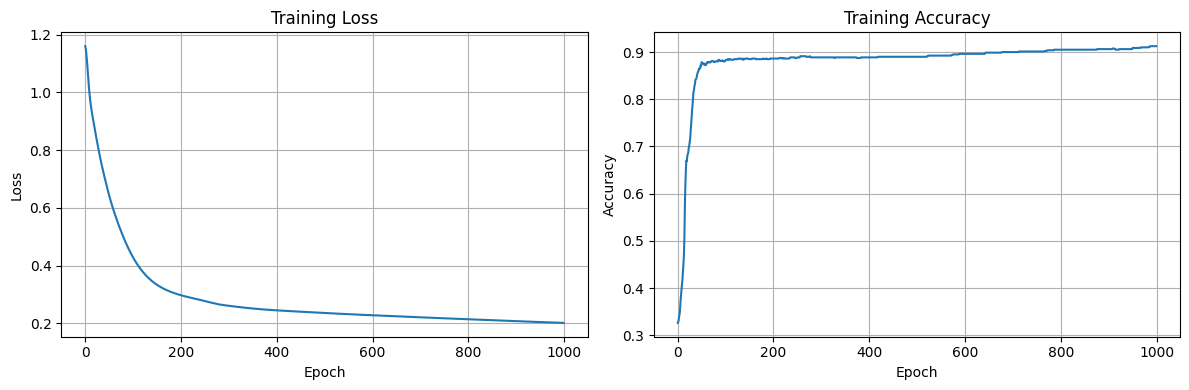

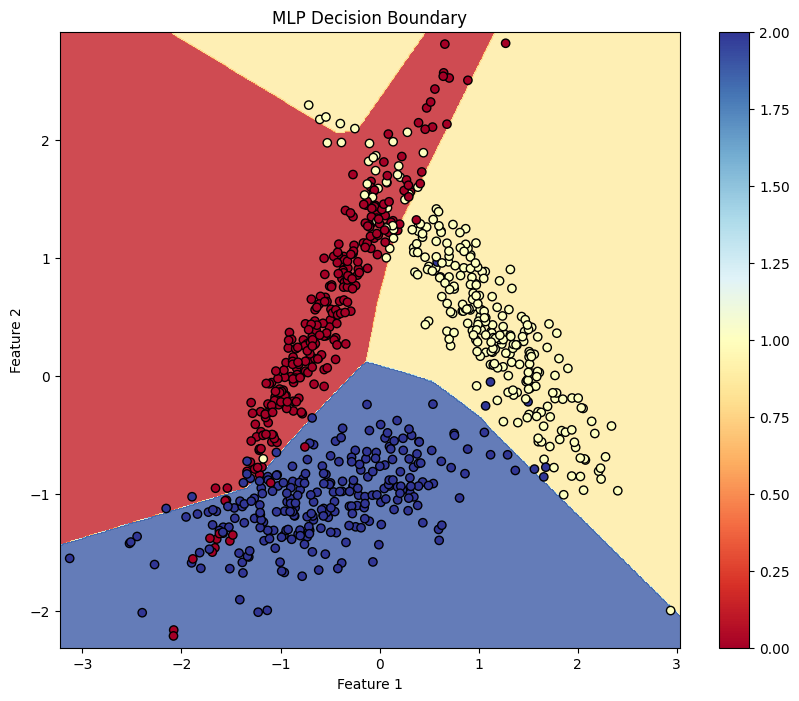

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

class MultilayerPerceptron:
    def __init__(self, layer_sizes, activation='sigmoid', learning_rate=0.01, 
                 max_epochs=1000, tolerance=1e-6, momentum=0.0, 
                 regularization=0.0, random_state=42):
        """
        Initialize Multilayer Perceptron
        
        Parameters:
        -----------
        layer_sizes : list
            List of integers representing the number of neurons in each layer
            Example: [2, 4, 3, 1] means 2 inputs, 4 neurons in first hidden layer,
                     3 neurons in second hidden layer, 1 output
        activation : str
            Activation function ('sigmoid', 'tanh', 'relu')
        learning_rate : float
            Learning rate for gradient descent
        max_epochs : int
            Maximum number of training epochs
        tolerance : float
            Convergence tolerance for early stopping
        momentum : float
            Momentum term for accelerated gradient descent
        regularization : float
            L2 regularization parameter
        random_state : int
            Random seed for reproducibility
        """
        self.layer_sizes = layer_sizes
        self.activation_name = activation
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.tolerance = tolerance
        self.momentum = momentum
        self.regularization = regularization
        
        # Set random seed
        np.random.seed(random_state)
        
        # Initialize weights and biases
        self.weights = []
        self.biases = []
        self.velocity_weights = []  # For momentum
        self.velocity_biases = []   # For momentum
        
        # Xavier/Glorot initialization
        for i in range(len(layer_sizes) - 1):
            # Xavier initialization
            limit = np.sqrt(6.0 / (layer_sizes[i] + layer_sizes[i + 1]))
            weight = np.random.uniform(-limit, limit, (layer_sizes[i], layer_sizes[i + 1]))
            bias = np.zeros((1, layer_sizes[i + 1]))
            
            self.weights.append(weight)
            self.biases.append(bias)
            self.velocity_weights.append(np.zeros_like(weight))
            self.velocity_biases.append(np.zeros_like(bias))
        
        # Set activation functions
        self.activation, self.activation_derivative = self._get_activation_functions()
        
        # Training history
        self.loss_history = []
        self.accuracy_history = []
    
    def _get_activation_functions(self):
        """Get activation function and its derivative"""
        if self.activation_name == 'sigmoid':
            def activation(x):
                return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
            
            def activation_derivative(x):
                return x * (1 - x)
        
        elif self.activation_name == 'tanh':
            def activation(x):
                return np.tanh(x)
            
            def activation_derivative(x):
                return 1 - x**2
        
        elif self.activation_name == 'relu':
            def activation(x):
                return np.maximum(0, x)
            
            def activation_derivative(x):
                return (x > 0).astype(float)
        
        else:
            raise ValueError(f"Unsupported activation function: {self.activation_name}")
        
        return activation, activation_derivative
    
    def forward_propagation(self, X):
        """
        Forward propagation through the network
        
        Parameters:
        -----------
        X : ndarray, shape (n_samples, n_features)
            Input data
            
        Returns:
        --------
        activations : list
            List of activations for each layer
        """
        activations = [X]
        current_input = X
        
        for i in range(len(self.weights)):
            # Linear transformation
            z = np.dot(current_input, self.weights[i]) + self.biases[i]
            
            # Apply activation function
            if i == len(self.weights) - 1:  # Output layer
                # Use sigmoid for binary classification, linear for regression
                if self.layer_sizes[-1] == 1:
                    a = self.activation(z)  # Binary classification
                else:
                    a = self._softmax(z)  # Multi-class classification
            else:  # Hidden layers
                a = self.activation(z)
            
            activations.append(a)
            current_input = a
        
        return activations
    
    def _softmax(self, x):
        """Softmax activation for multi-class classification"""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def backward_propagation(self, X, y, activations):
        """
        Backward propagation to compute gradients
        
        Parameters:
        -----------
        X : ndarray, shape (n_samples, n_features)
            Input data
        y : ndarray, shape (n_samples, n_outputs)
            Target values
        activations : list
            Activations from forward propagation
            
        Returns:
        --------
        weight_gradients : list
            Gradients for weights
        bias_gradients : list
            Gradients for biases
        """
        m = X.shape[0]
        weight_gradients = []
        bias_gradients = []
        
        # Calculate output layer error
        output_error = activations[-1] - y
        
        # Backpropagate errors
        errors = [output_error]
        
        # Calculate errors for hidden layers
        for i in range(len(self.weights) - 1, 0, -1):
            error = np.dot(errors[0], self.weights[i].T) * self.activation_derivative(activations[i])
            errors.insert(0, error)
        
        # Calculate gradients
        for i in range(len(self.weights)):
            weight_grad = np.dot(activations[i].T, errors[i]) / m
            bias_grad = np.mean(errors[i], axis=0, keepdims=True)
            
            # Add L2 regularization
            if self.regularization > 0:
                weight_grad += self.regularization * self.weights[i]
            
            weight_gradients.append(weight_grad)
            bias_gradients.append(bias_grad)
        
        return weight_gradients, bias_gradients
    
    def update_weights(self, weight_gradients, bias_gradients):
        """Update weights and biases using gradient descent with momentum"""
        for i in range(len(self.weights)):
            # Update velocity (momentum)
            self.velocity_weights[i] = (self.momentum * self.velocity_weights[i] - 
                                      self.learning_rate * weight_gradients[i])
            self.velocity_biases[i] = (self.momentum * self.velocity_biases[i] - 
                                     self.learning_rate * bias_gradients[i])
            
            # Update weights and biases
            self.weights[i] += self.velocity_weights[i]
            self.biases[i] += self.velocity_biases[i]
    
    def compute_loss(self, y_true, y_pred):
        """Compute loss (Mean Squared Error for regression, Cross-entropy for classification)"""
        m = y_true.shape[0]
        
        if self.layer_sizes[-1] == 1:  # Binary classification
            # Binary cross-entropy
            y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
            loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        else:  # Multi-class classification
            # Categorical cross-entropy
            y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
            loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        
        # Add L2 regularization term
        if self.regularization > 0:
            l2_penalty = sum(np.sum(w**2) for w in self.weights)
            loss += 0.5 * self.regularization * l2_penalty / m
        
        return loss
    
    def compute_accuracy(self, y_true, y_pred):
        """Compute classification accuracy"""
        if self.layer_sizes[-1] == 1:  # Binary classification
            predictions = (y_pred > 0.5).astype(int)
            return np.mean(predictions == y_true)
        else:  # Multi-class classification
            predictions = np.argmax(y_pred, axis=1)
            y_true_labels = np.argmax(y_true, axis=1)
            return np.mean(predictions == y_true_labels)
    
    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        """
        Train the multilayer perceptron
        
        Parameters:
        -----------
        X : ndarray, shape (n_samples, n_features)
            Training data
        y : ndarray, shape (n_samples, n_outputs)
            Training targets
        X_val : ndarray, optional
            Validation data
        y_val : ndarray, optional
            Validation targets
        verbose : bool
            Whether to print training progress
        """
        self.loss_history = []
        self.accuracy_history = []
        
        # Ensure y is 2D
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        prev_loss = float('inf')
        
        for epoch in range(self.max_epochs):
            # Forward propagation
            activations = self.forward_propagation(X)
            y_pred = activations[-1]
            
            # Compute loss and accuracy
            loss = self.compute_loss(y, y_pred)
            accuracy = self.compute_accuracy(y, y_pred)
            
            self.loss_history.append(loss)
            self.accuracy_history.append(accuracy)
            
            # Backward propagation
            weight_gradients, bias_gradients = self.backward_propagation(X, y, activations)
            
            # Update weights
            self.update_weights(weight_gradients, bias_gradients)
            
            # Print progress
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d}: Loss = {loss:.6f}, Accuracy = {accuracy:.4f}")
                
                if X_val is not None and y_val is not None:
                    val_pred = self.predict_proba(X_val)
                    val_loss = self.compute_loss(y_val, val_pred)
                    val_acc = self.compute_accuracy(y_val, val_pred)
                    print(f"           Val Loss = {val_loss:.6f}, Val Accuracy = {val_acc:.4f}")
            
            # Early stopping
            if abs(prev_loss - loss) < self.tolerance:
                if verbose:
                    print(f"Converged at epoch {epoch}")
                break
            prev_loss = loss
    
    def predict_proba(self, X):
        """Predict class probabilities"""
        activations = self.forward_propagation(X)
        return activations[-1]
    
    def predict(self, X):
        """Make predictions"""
        y_pred = self.predict_proba(X)
        
        if self.layer_sizes[-1] == 1:  # Binary classification
            return (y_pred > 0.5).astype(int)
        else:  # Multi-class classification
            return np.argmax(y_pred, axis=1)
    
    def plot_training_history(self):
        """Plot training loss and accuracy"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        ax1.plot(self.loss_history)
        ax1.set_title('Training Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.grid(True)
        
        ax2.plot(self.accuracy_history)
        ax2.set_title('Training Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def plot_decision_boundary(self, X, y, resolution=0.01):
        """Plot decision boundary for 2D data"""
        if X.shape[1] != 2:
            print("Decision boundary plotting only available for 2D data")
            return
        
        # Create a mesh
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                            np.arange(y_min, y_max, resolution))
        
        # Make predictions on the mesh
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        Z = self.predict_proba(mesh_points)
        
        if self.layer_sizes[-1] == 1:
            Z = Z.reshape(xx.shape)
        else:
            Z = np.argmax(Z, axis=1).reshape(xx.shape)
        
        # Plot
        plt.figure(figsize=(10, 8))
        plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
        
        # Plot data points
        if y.ndim > 1:
            y = np.argmax(y, axis=1) if y.shape[1] > 1 else y.ravel()
        
        scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='black')
        plt.colorbar(scatter)
        plt.title('MLP Decision Boundary')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.show()

# Example usage and demonstration
def demo_binary_classification():
    """Demonstrate MLP on binary classification"""
    print("=== Binary Classification Demo ===")
    
    # Generate data
    X, y = make_circles(n_samples=1000, noise=0.1, factor=0.3, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Create and train MLP
    mlp = MultilayerPerceptron(
        layer_sizes=[2, 8, 6, 1],
        activation='tanh',
        learning_rate=0.1,
        max_epochs=1000,
        momentum=0.9,
        regularization=0.001
    )
    
    mlp.fit(X_train_scaled, y_train, X_test_scaled, y_test)
    
    # Evaluate
    train_accuracy = mlp.compute_accuracy(y_train.reshape(-1, 1), mlp.predict_proba(X_train_scaled))
    test_accuracy = mlp.compute_accuracy(y_test.reshape(-1, 1), mlp.predict_proba(X_test_scaled))
    
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    # Plot results
    mlp.plot_training_history()
    mlp.plot_decision_boundary(X_train_scaled, y_train)
    
    return mlp

def demo_multiclass_classification():
    """Demonstrate MLP on multi-class classification"""
    print("\n=== Multi-class Classification Demo ===")
    
    # Generate data
    X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, 
                              n_informative=2, n_clusters_per_class=1, n_classes=3, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert labels to one-hot encoding
    def to_one_hot(y, n_classes):
        one_hot = np.zeros((len(y), n_classes))
        one_hot[np.arange(len(y)), y] = 1
        return one_hot
    
    y_train_oh = to_one_hot(y_train, 3)
    y_test_oh = to_one_hot(y_test, 3)
    
    # Create and train MLP
    mlp = MultilayerPerceptron(
        layer_sizes=[2, 10, 8, 3],
        activation='relu',
        learning_rate=0.01,
        max_epochs=1000,
        momentum=0.9,
        regularization=0.001
    )
    
    mlp.fit(X_train_scaled, y_train_oh, X_test_scaled, y_test_oh)
    
    # Evaluate
    train_accuracy = mlp.compute_accuracy(y_train_oh, mlp.predict_proba(X_train_scaled))
    test_accuracy = mlp.compute_accuracy(y_test_oh, mlp.predict_proba(X_test_scaled))
    
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    # Plot results
    mlp.plot_training_history()
    mlp.plot_decision_boundary(X_train_scaled, y_train)
    
    return mlp

def demo_xor_problem():
    """Demonstrate MLP solving XOR problem"""
    print("\n=== XOR Problem Demo ===")
    
    # XOR dataset
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])
    
    # Create and train MLP
    mlp = MultilayerPerceptron(
        layer_sizes=[2, 4, 1],
        activation='sigmoid',
        learning_rate=1.0,
        max_epochs=5000
    )
    
    mlp.fit(X, y)
    
    # Test predictions
    predictions = mlp.predict_proba(X)
    print("\nXOR Truth Table:")
    print("Input  | Target | Predicted | Rounded")
    print("-------|--------|-----------|--------")
    for i in range(len(X)):
        pred = predictions[i, 0]
        rounded = round(pred)
        print(f"{X[i]}  |   {y[i, 0]}    |   {pred:.4f}   |    {rounded}")
    
    mlp.plot_training_history()
    
    return mlp

if __name__ == "__main__":
    # Run demonstrations
    print("Multilayer Perceptron Implementation")
    print("====================================")
    
    # XOR Problem
    demo_xor_problem()
    
    # Binary Classification
    demo_binary_classification()
    
    # Multi-class Classification
    demo_multiclass_classification()